<a href="https://colab.research.google.com/github/DABMASTER-Brought-me-into-this/ZeroToHeroColabCollection/blob/main/makemorept5_recal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import math
%matplotlib inline

In [ ]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-05-31 21:26:45--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.08s   

2026-05-31 21:26:46 (2.69 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
# Cleansing the Data
data = open('names.txt').readlines()
data = [string.strip('\n') for string in data]
data[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
# Building the Indexing
letters = sorted(list(set("".join(data))))
stoi = {letter: i + 1 for i, letter in enumerate(letters)}
stoi['.'] = 0
itos = {value: key for key,value in stoi.items()}

In [ ]:
# Hyperparameters
context_size = 8
n_embd = 24
n_hidden = 128
pair_size = 2
batch_size = 64
epochs = 30

In [ ]:
# Building the Dataset
def build_dataset(data, context_size):
  # Building the Inputs/Ouputs
  X, Y = [], []

  # Accessing All Names
  for name in data:
    # Getting the Context
    context = [0] * context_size
    for letter in name:
      # Adding the Context
      X.append(context)
      Y.append([stoi[letter]]) # Adding the Next Letter
      context = context[1:] + [stoi[letter]] # Adding the New Word Now
    X.append(context)
    Y.append([0])

  return X, Y

X, Y = build_dataset(data, context_size)
# The original line caused an error because 'i' was a list, but itos expects an integer.
# To correctly decode the contexts, we need to iterate through each element within the context list.
[[itos[j] for j in context] for context in X[:20]], [[itos[j] for j in context] for context in Y[:20]]

([['.', '.', '.', '.', '.', '.', '.', '.'],
  ['.', '.', '.', '.', '.', '.', '.', 'e'],
  ['.', '.', '.', '.', '.', '.', 'e', 'm'],
  ['.', '.', '.', '.', '.', 'e', 'm', 'm'],
  ['.', '.', '.', '.', 'e', 'm', 'm', 'a'],
  ['.', '.', '.', '.', '.', '.', '.', '.'],
  ['.', '.', '.', '.', '.', '.', '.', 'o'],
  ['.', '.', '.', '.', '.', '.', 'o', 'l'],
  ['.', '.', '.', '.', '.', 'o', 'l', 'i'],
  ['.', '.', '.', '.', 'o', 'l', 'i', 'v'],
  ['.', '.', '.', 'o', 'l', 'i', 'v', 'i'],
  ['.', '.', 'o', 'l', 'i', 'v', 'i', 'a'],
  ['.', '.', '.', '.', '.', '.', '.', '.'],
  ['.', '.', '.', '.', '.', '.', '.', 'a'],
  ['.', '.', '.', '.', '.', '.', 'a', 'v'],
  ['.', '.', '.', '.', '.', 'a', 'v', 'a'],
  ['.', '.', '.', '.', '.', '.', '.', '.'],
  ['.', '.', '.', '.', '.', '.', '.', 'i'],
  ['.', '.', '.', '.', '.', '.', 'i', 's'],
  ['.', '.', '.', '.', '.', 'i', 's', 'a']],
 [['e'],
  ['m'],
  ['m'],
  ['a'],
  ['.'],
  ['o'],
  ['l'],
  ['i'],
  ['v'],
  ['i'],
  ['a'],
  ['.'],
  ['a'],
  

In [ ]:
# Shuffling the Dataset
combined_list = list(zip(X, Y))
random.shuffle(combined_list)
X, Y = zip(*combined_list)

# Turning them into Numpy Ndarrays
n = int(len(X) * 0.8)
Xtr, Ytr = np.array(X[:n], dtype = np.float32), np.array(Y[:n], dtype = np.float32)
Xte, Yte = np.array(X[n:], dtype = np.float32), np.array(Y[n:], dtype = np.float32)
Xtr[:8]

array([[ 0.,  0., 19.,  1., 11., 19.,  8.,  1.],
       [ 0.,  0.,  0.,  0., 16.,  5., 18., 19.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 14.,  1.],
       [ 0.,  0.,  0.,  0.,  0., 21., 11.,  9.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., 19.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.],
       [ 0.,  0.,  0.,  0., 12.,  5.,  1.,  8.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]], dtype=float32)

In [ ]:
class Embedding:
  def __init__(self, vocab_size, ndims):
    self.w = np.random.randn(vocab_size, ndims)
    self.dw = np.zeros_like(self.w)

  def __call__(self, IX):
    self.x = IX
    self.out = self.w[IX.astype(int)]
    return self.out

  def parameters(self):
    return [(self.w, self.dw)]

  def backward(self, dup):
    np.add.at(self.dw, self.x.astype(int), dup)

#------------------------------------------------------------------

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    self.x_shape = x.shape
    if x.ndim == 3:
      B, T, C = x.shape
      x = x.reshape(B, T // self.n, C * self.n)
      if x.shape[1] == 1:
        x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

  def backward(self, dup):
    return dup.reshape(self.x_shape)

#------------------------------------------------------------------

class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.w = np.random.randn(fan_in, fan_out) * (5/3) / np.sqrt(fan_in)
    self.b = np.zeros(fan_out) if bias else None
    self.dw = np.zeros_like(self.w)
    if bias:
        self.db = np.zeros_like(self.b)

  def __call__(self, x):
    self.x = x
    self.out = x @ self.w
    if self.b is not None:
      self.out += self.b
    return self.out

  def backward(self, dup):
    self.dw += self.x.reshape(-1, self.x.shape[-1]).T @ dup.reshape(-1, dup.shape[-1])
    if self.b is not None:
      self.db += dup.reshape(-1, self.db.shape[0]).sum(0)
    self.dout = dup.reshape(-1, dup.shape[-1]) @ self.w.T
    if self.x.ndim == 3:
      return self.dout.reshape(self.x.shape)
    return self.dout

  def parameters(self):
    params = [(self.w, self.dw)]
    if self.b is not None:
      params.append((self.b, self.db))
    return params

#------------------------------------------------------------------

class BatchNorm:
  def __init__(self, dims, eps = 1e-5, momentum = 0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.g = np.ones(dims)
    self.b = np.zeros(dims)
    self.dg = np.zeros_like(self.g)
    self.db = np.zeros_like(self.b)
    self.running_mean = np.zeros(dims)
    self.running_var = np.zeros(dims)

  def __call__(self, x):
    self.x = x
    if self.training:
      self.xmean = x.mean(axis = tuple(range(x.ndim - 1)), keepdims=True)
      self.xvar = x.var(axis = tuple(range(x.ndim - 1)), keepdims=True)
      self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * self.xmean
      self.running_var = (1 - self.momentum) * self.running_var + self.momentum * self.xvar
    else:
      self.xmean = self.running_mean
      self.xvar = self.running_var

    self.xhat = (x - self.xmean)/np.sqrt(self.xvar + self.eps)
    self.out = self.g * self.xhat + self.b
    return self.out

  def parameters(self):
    return [(self.g, self.dg), (self.b, self.db)]

  def backward(self, dup):
    dims = dup.reshape(-1, dup.shape[-1]).shape[0]
    self.dg = (dup * self.xhat).sum(axis=tuple(range(dup.ndim - 1)))
    self.db = dup.sum(axis=tuple(range(dup.ndim - 1)))
    self.dout = (self.g)/(dims * np.sqrt(self.xvar + self.eps)) * (dims * dup - dup.sum(axis=tuple(range(dup.ndim - 1))) - self.xhat * (dup * self.xhat).sum(axis=tuple(range(dup.ndim - 1))))
    return self.dout

#------------------------------------------------------------------

class Tanh:
  def __call__(self, x):
    self.out = np.tanh(x)
    return self.out

  def parameters(self):
    return []

  def backward(self, dup):
    return (1 - self.out ** 2) * dup

#------------------------------------------------------------------

class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

  def backward(self, dlogits):
    for layer in reversed(self.layers):
      dlogits = layer.backward(dlogits)

In [ ]:
# Building the Layers
layers = []
layers.append(Embedding(len(stoi), n_embd))
layers.extend([FlattenConsecutive(pair_size), Linear(48, 68), BatchNorm(68), Tanh()])
layers.extend([FlattenConsecutive(pair_size), Linear(68*2, 68), BatchNorm(68), Tanh()])
layers.extend([FlattenConsecutive(pair_size), Linear(68*2, 68), BatchNorm(68), Tanh()])
layers.extend([Linear(68, 27)])


# Feeding them into Sequential (our own build)
model = Sequential(layers)

In [ ]:
# Tracking Data
lr = 0.1
lri = []
lossi = []
steppi = []

In [ ]:
# Trynna train w/ epochs insteads of steps
prev_loss = 2.7
for epoch in range(epochs):
  indices = np.random.permutation(Xtr.shape[0])

  for step in range(Xtr.shape[0]//batch_size):
    # Getting the Batch Indexes
    start_idx = step * batch_size
    end_idx = start_idx + batch_size
    batch_ix = indices[start_idx : end_idx]

    # Indexing at the random indicies
    Xb = Xtr[batch_ix]
    Yb = Ytr[batch_ix].astype(int).flatten()

    # Zero out gradients
    for p, grad in model.parameters():
      grad.fill(0)

    # Forward Pass
    logits = model(Xb)
    # Cross entropy loss calculation
    logit_maxes = np.max(logits, axis=1, keepdims=True)
    norm_logits = logits - logit_maxes # stability
    counts = np.exp(norm_logits)
    counts_sum = counts.sum(axis=1, keepdims=True)
    probs = counts / counts_sum
    loss = -np.log(probs[np.arange(batch_size), Yb] + 1e-5).mean()
    lossi.append(loss)

    # Backward Pass
    dlogits = probs
    dlogits[np.arange(batch_size), Yb] -= 1
    dlogits /= batch_size
    model.backward(dlogits)

    # Bold Driver Optimization
    if prev_loss > loss:
      lr *= 1.05
    elif loss < prev_loss:
      lr *= 0.5
    else:
      lr *= 1

    lr = max(min(lr, 0.95), 1e-5)
    lri.append(lr)
    prev_loss = loss
    for p, grad in model.parameters():
      p += -lr * grad

  print(f'Epoch {epoch+1}/{epochs} | Loss: {loss:.4f}')

Epoch 1/30 | Loss: 2.3385
Epoch 2/30 | Loss: 2.0089
Epoch 3/30 | Loss: 2.0606
Epoch 4/30 | Loss: 1.8837
Epoch 5/30 | Loss: 2.0786
Epoch 6/30 | Loss: 2.1228
Epoch 7/30 | Loss: 1.9108
Epoch 8/30 | Loss: 2.1940
Epoch 9/30 | Loss: 2.0527
Epoch 10/30 | Loss: 2.3673
Epoch 11/30 | Loss: 2.1535
Epoch 12/30 | Loss: 2.4939
Epoch 13/30 | Loss: 2.0376
Epoch 14/30 | Loss: 2.1209
Epoch 15/30 | Loss: 1.9010
Epoch 16/30 | Loss: 2.0323
Epoch 17/30 | Loss: 1.9881
Epoch 18/30 | Loss: 2.0047
Epoch 19/30 | Loss: 1.8085
Epoch 20/30 | Loss: 2.0506
Epoch 21/30 | Loss: 2.0168
Epoch 22/30 | Loss: 1.8872
Epoch 23/30 | Loss: 2.3656
Epoch 24/30 | Loss: 2.0680
Epoch 25/30 | Loss: 2.0234
Epoch 26/30 | Loss: 2.1224
Epoch 27/30 | Loss: 1.9488
Epoch 28/30 | Loss: 1.9482
Epoch 29/30 | Loss: 2.0154
Epoch 30/30 | Loss: 2.1676


In [ ]:
# Getting # of steps
steppi = [i for i in range(len(lossi))]

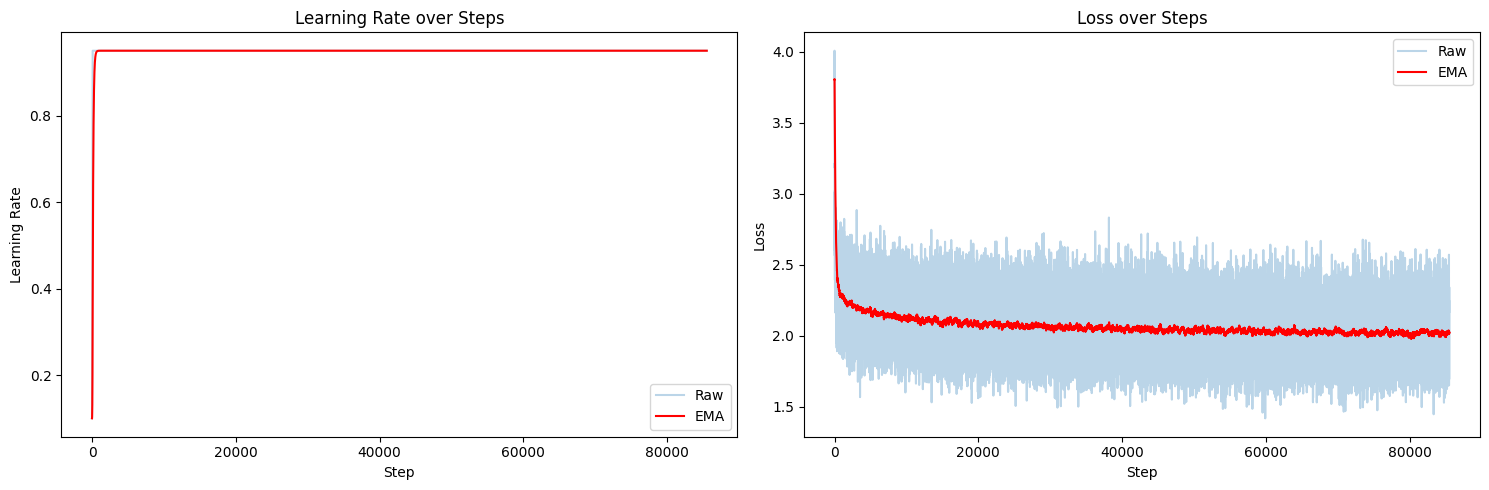

In [ ]:
def get_ema(data, alpha=0.01):
    ema = [data[0]]
    for x in data[1:]:
        ema.append(ema[-1] * (1 - alpha) + x * alpha)
    return ema

plt.figure(figsize=(15, 5))

# Plotting Learning Rate
plt.subplot(1, 2, 1)
plt.plot(steppi, lri, alpha=0.3, label='Raw')
plt.plot(steppi, get_ema(lri), color='red', label='EMA')
plt.title('Learning Rate over Steps')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(steppi, lossi, alpha=0.3, label='Raw')
plt.plot(steppi, get_ema(lossi), color='red', label='EMA')
plt.title('Loss over Steps')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Corrected Testing Loss Calculation
for layer in model.layers:
  if hasattr(layer, 'training'):
    layer.training = False

# Forward pass on full test set
logits = model(Xte)
logit_maxes = np.max(logits, axis=1, keepdims=True)
norm_logits = logits - logit_maxes
counts = np.exp(norm_logits)
probs = counts / counts.sum(axis=1, keepdims=True)

# Use the actual length of Yte instead of batch_size
test_loss = -np.log(probs[np.arange(len(Yte)), Yte.astype(int).flatten()] + 1e-5).mean()
print(f'Final Test Loss: {test_loss:.4f}')

Final Test Loss: 2.0803


In [ ]:
a = ['.', 'b', 'e']
print(a[-2:])

['b', 'e']


In [ ]:
name = [0] * 8
np.array(name[-8:]).reshape(1, 8).shape

(1, 8)

In [ ]:
# Sampling From the Model
for layer in model.layers:
  if hasattr(layer, 'training'):
    layer.training = False

for example in range(20):
  name = [0] * 8
  while True:
    logits = model(np.array(name[-8:]).reshape(1,8))
    logit_maxes = np.max(logits, axis=1, keepdims=True)
    norm_logits = logits - logit_maxes
    counts = np.exp(norm_logits)
    probs = counts / counts.sum(axis=1, keepdims=True)
    probs = probs.reshape(-1)

    next_char = np.random.choice(list(range(len(probs.tolist()))), p = probs)
    if next_char == 0:
      print("".join(list(itos[char] for char in name[8:])).capitalize())
      break
    else:
      name.append(int(next_char))

Suthanzuri
Jazarly
Breck
Hulleon
Atley
Leel
Alavin
Leana
Haddi
Camv
Tegen
Thotta
Amarion
Kiha
Makad
Acem
Keere
Alilina
Amelyz
Dimre


In [ ]:
name = [0] * 8
while True:
  logits = model(np.array(name[-8:]).reshape(1,8))
  logit_maxes = np.max(logits, axis=1, keepdims=True)
  norm_logits = logits - logit_maxes
  counts = np.exp(norm_logits)
  probs = counts / counts.sum(axis=1, keepdims=True)
  probs = probs.reshape(-1)

  next_char = np.argmax(probs)
  if next_char == 0:
    print("".join(list(itos[char] for char in name[8:])).capitalize())
    break
  else:
    name.append(int(next_char))

Alexandro
